In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Set visualization style
sns.set(style="whitegrid")
%matplotlib inline

Total Samples: 2151
Feature Count: 168

Class Distribution:
label
1    1484
0     667
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_11400\3170204699.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


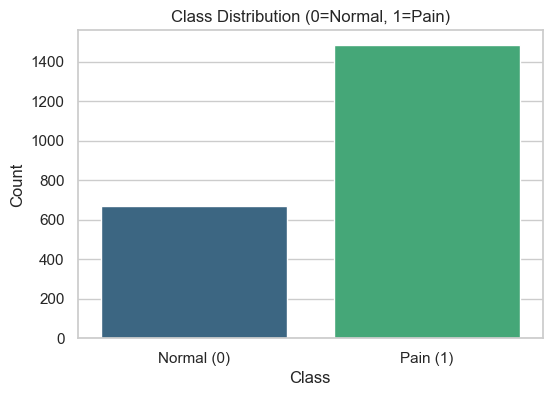

In [13]:
# Load the data generated in the previous step
df = pd.read_csv("../data/processed/AudioProcessed1.csv")

# Display basic info
print(f"Total Samples: {len(df)}")
print(f"Feature Count: {len(df.columns) - 1}") # Minus 1 for the label column

# Check class distribution
class_counts = df['label'].value_counts()
print("\nClass Distribution:")
print(class_counts)

# Visualize the balance
plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Class Distribution (0=Normal, 1=Pain)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks([0, 1], ['Normal (0)', 'Pain (1)'])
plt.show()

In [14]:
# Separate Features (X) and Target (y)
X = df.drop('label', axis=1)
y = df['label']

# Split: 80% for Training, 20% for Testing
# stratify=y ensures both sets have a mix of Pain/Normal
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Testing shapes:  X={X_test.shape},  y={y_test.shape}")

Training shapes: X=(1720, 168), y=(1720,)
Testing shapes:  X=(431, 168),  y=(431,)


In [15]:
# Initialize the model
# n_estimators=100: Uses 100 decision trees
# class_weight='balanced': Helps because your "Normal" class is now smaller than "Pain"
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

print("Training started...")
model.fit(X_train, y_train)
print("Training complete!")

Training started...
Training complete!


In [16]:
# Generate predictions
y_pred = model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"--- MODEL PERFORMANCE ---")
print(f"Accuracy: {accuracy:.2%}")
print(f"F1-Score: {f1:.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Pain']))

--- MODEL PERFORMANCE ---
Accuracy: 70.53%
F1-Score: 78.29%

Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       0.52      0.56      0.54       134
        Pain       0.80      0.77      0.78       297

    accuracy                           0.71       431
   macro avg       0.66      0.67      0.66       431
weighted avg       0.71      0.71      0.71       431



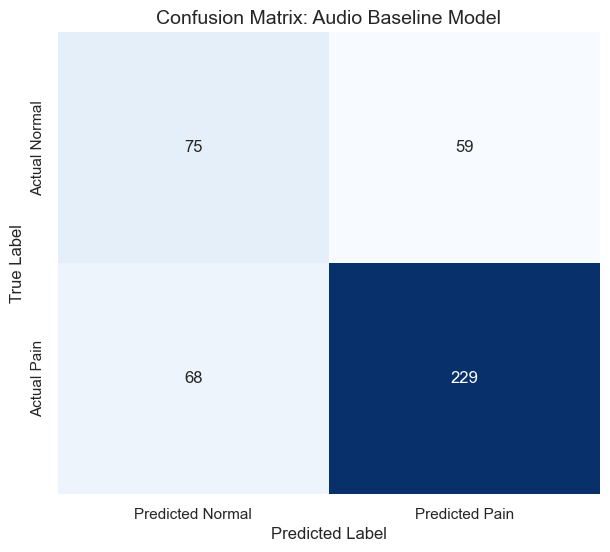

In [17]:
# Plot Confusion Matrix
plt.figure(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Normal', 'Predicted Pain'],
            yticklabels=['Actual Normal', 'Actual Pain'])

plt.title('Confusion Matrix: Audio Baseline Model', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

In [18]:
# Save model to disk
joblib.dump(model, '../saved_models/audio_pain_model1.pkl')
print("Model1 saved successfully as '../../backEnd/mlModels/Cry/audio_pain_model1.pkl'")


Model1 saved successfully as '../../backEnd/mlModels/Cry/audio_pain_model1.pkl'


In [19]:
from sklearn.ensemble import GradientBoostingClassifier

# 1. Initialize Gradient Boosting (often beats Random Forest for audio)
gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)

print("Training Gradient Boosting Model...")
gb_model.fit(X_train, y_train)

# 2. Evaluate
y_pred_gb = gb_model.predict(X_test)

print(f"--- GRADIENT BOOSTING RESULTS ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.2%}")
print(f"F1-Score (Pain): {f1_score(y_test, y_pred_gb):.2%}")
print("\nReport:")
print(classification_report(y_test, y_pred_gb, target_names=['Normal', 'Pain']))

# 3. If this is better, save THIS model instead
if accuracy_score(y_test, y_pred_gb) > accuracy_score(y_test, y_pred):
    joblib.dump(gb_model, '../../backEnd/mlModels/Cry/audio_pain_model2.pkl')
    print("audio_pain_model2 saved!")

Training Gradient Boosting Model...


--- GRADIENT BOOSTING RESULTS ---
Accuracy: 73.32%
F1-Score (Pain): 80.48%

Report:
              precision    recall  f1-score   support

      Normal       0.57      0.59      0.58       134
        Pain       0.81      0.80      0.80       297

    accuracy                           0.73       431
   macro avg       0.69      0.69      0.69       431
weighted avg       0.74      0.73      0.73       431



FileNotFoundError: [Errno 2] No such file or directory: '../../backEnd/mlModels/Cry/audio_pain_model2.pkl'

In [ ]:
import joblib
import os
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 1. Initialize Gradient Boosting
# n_estimators=200 means it will create 200 small decision trees to refine the result
gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)

print("Training Gradient Boosting Model...")
# Ensure X_train and y_train are already defined from your previous cells!
gb_model.fit(X_train, y_train)

# 2. Evaluate
y_pred_gb = gb_model.predict(X_test)

print(f"--- GRADIENT BOOSTING RESULTS ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.2%}")
# Note: average='weighted' handles multi-class data better if you have >2 classes
print(f"F1-Score: {f1_score(y_test, y_pred_gb, average='weighted'):.2%}")
print("\nReport:")
print(classification_report(y_test, y_pred_gb))

# 3. Save the Model
# We will save it to the current folder first to avoid "Path Not Found" errors
save_name = "../../backEnd/mlModels/Cry/audio_pain_model3.pkl"
joblib.dump(gb_model, save_name)
print(f"✅ Success! Model saved as '{save_name}' in this folder.")

Training Gradient Boosting Model...
--- GRADIENT BOOSTING RESULTS ---
Accuracy: 73.32%
F1-Score: 73.45%

Report:
              precision    recall  f1-score   support

           0       0.57      0.59      0.58       134
           1       0.81      0.80      0.80       297

    accuracy                           0.73       431
   macro avg       0.69      0.69      0.69       431
weighted avg       0.74      0.73      0.73       431

✅ Success! Model saved as '../saved_models/audio_pain_model3.pkl' in this folder.


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler  # <--- NEW IMPORT
import joblib
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 1. Initialize Scaler and Model
scaler = StandardScaler() # <--- NEW: The "Translator" for numbers
gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)

print("Scaling Data...")
# Fit the scaler on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)
# Just transform the test data (don't refit)
X_test_scaled = scaler.transform(X_test)

print("Training Gradient Boosting Model...")
# Train on the SCALED data, not X_train
gb_model.fit(X_train_scaled, y_train) 

# 2. Evaluate
y_pred_gb = gb_model.predict(X_test_scaled)

print(f"--- GRADIENT BOOSTING RESULTS ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.2%}")
print(f"F1-Score: {f1_score(y_test, y_pred_gb, average='weighted'):.2%}")
print("\nReport:")
print(classification_report(y_test, y_pred_gb))

# 3. Save BOTH the Model AND the Scaler
# We need both files for the backend to work!
joblib.dump(gb_model, '../../backEnd/mlModels/Cry/audio_pain_model4.pkl')
joblib.dump(scaler, '../../backEnd/mlModels/Cry/scaler.pkl')  # <--- CRITICAL SAVE
print("✅ Success! Saved 'audio_pain_model4.pkl' and 'scaler.pkl'")

Scaling Data...
Training Gradient Boosting Model...
--- GRADIENT BOOSTING RESULTS ---
Accuracy: 73.09%
F1-Score: 73.29%

Report:
              precision    recall  f1-score   support

           0       0.56      0.60      0.58       134
           1       0.81      0.79      0.80       297

    accuracy                           0.73       431
   macro avg       0.69      0.69      0.69       431
weighted avg       0.74      0.73      0.73       431

✅ Success! Saved 'audio_pain_model4.pkl' and 'scaler.pkl'


In [1]:
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- 1. LOAD THE NEW DATA ---
# Make sure this matches the file name you just created!
DATA_FILE = "../data/processed/AudioProcessed_3Class.csv"

if not os.path.exists(DATA_FILE):
    print(f"❌ Error: File not found at {DATA_FILE}")
else:
    print(f"✅ Loading data from: {DATA_FILE}")
    df = pd.read_csv(DATA_FILE)

    # --- 2. PREPARE DATA ---
    # Separate Features (X) and Labels (y)
    X = df.drop('label', axis=1)
    y = df['label']

    print(f"Data Shape: {X.shape}")
    print(f"Class Distribution:\n{y.value_counts()}")

    # Split into Train and Test (80% Train, 20% Test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # --- 3. SCALING (CRITICAL) ---
    # We MUST use a scaler because we have complex features now
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # --- 4. TRAIN MODEL (Gradient Boosting) ---
    print("\n🚀 Training Gradient Boosting Model (this may take a moment)...")
    gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
    gb_model.fit(X_train_scaled, y_train)

    # --- 5. EVALUATE ---
    y_pred = gb_model.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n🏆 Model Accuracy: {accuracy:.2%}")
    
    print("\n--- Classification Report ---")
    # Note: We now have 3 Target Names!
    print(classification_report(y_test, y_pred, target_names=['Hunger', 'Pain', 'Normal']))

    print("\n--- Confusion Matrix ---")
    print(confusion_matrix(y_test, y_pred))

    # --- 6. SAVE MODEL & SCALER ---
    save_folder = '../../backEnd/mlModels/Cry/' # OR just 'saved_models' if that's your folder structure
    os.makedirs(save_folder, exist_ok=True)

    model_path = os.path.join(save_folder, 'audio_pain_model4.pkl')
    scaler_path = os.path.join(save_folder, 'scaler.pkl')

    joblib.dump(gb_model, model_path)
    joblib.dump(scaler, scaler_path)

    print(f"\n💾 SAVED SUCCESSFULLY!")
    print(f"   Model:  {model_path}")
    print(f"   Scaler: {scaler_path}")
    print("\n👉 NEXT STEP: Copy these 2 files to your 'backEnd/mlModels/Cry' folder!")

✅ Loading data from: ../data/processed/AudioProcessed_3Class.csv
Data Shape: (3297, 355)
Class Distribution:
label
0    1528
1    1484
2     285
Name: count, dtype: int64

🚀 Training Gradient Boosting Model (this may take a moment)...

🏆 Model Accuracy: 38.79%

--- Classification Report ---
              precision    recall  f1-score   support

      Hunger       0.37      0.40      0.38       306
        Pain       0.40      0.39      0.40       297
      Normal       0.40      0.35      0.37        57

    accuracy                           0.39       660
   macro avg       0.39      0.38      0.38       660
weighted avg       0.39      0.39      0.39       660


--- Confusion Matrix ---
[[121 161  24]
 [176 115   6]
 [ 29   8  20]]

💾 SAVED SUCCESSFULLY!
   Model:  ../../backEnd/mlModels/Cry/audio_pain_model4.pkl
   Scaler: ../../backEnd/mlModels/Cry/scaler.pkl

👉 NEXT STEP: Copy these 2 files to your 'backEnd/mlModels/Cry' folder!
